# Wikipedia Experiment - Feature Comparison on v3 Data
Uses existing v3_features.csv (80 articles, 40 pairs) - no new API calls needed.

## What this tests

- Experiment 1: Baseline (v3 as-is)
- Experiment 2: Expanded hedging word list
- Experiment 3: Feature subsets (linguistic / structural / behavioral)
- Experiment 4: Topic-controlled analysis
- Experiment 5: Pair-level Wilcoxon (more powerful than Mann-Whitney)
- Experiment 6: Random Forest vs Logistic Regression agreement


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, json, os, re
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import mannwhitneyu, norm, wilcoxon

df = pd.read_csv("v3_features.csv")
print(f"Loaded {len(df)} articles")
print(f"  Contested : {(df.label==0).sum()}")
print(f"  Stable    : {(df.label==1).sum()}")
print(f"  Topics    : {df['topic'].value_counts().to_dict()}")

c_df = df[df.label==0]
s_df = df[df.label==1]

BASELINE_FEATURES = [
    "hedging_density","def_ratio",
    "citation_count","section_count",
    "unique_editors","age_days","recency_ratio",
    "revert_count","talk_words","talk_editors",
]

def run_model(feature_cols, label="experiment", data=None):
    if data is None:
        data = df
    d    = data[feature_cols + ["label"]].dropna()
    X    = StandardScaler().fit_transform(d[feature_cols].values)
    y    = d["label"].values
    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    m    = LogisticRegression(class_weight="balanced",
                               max_iter=1000, random_state=42)
    f1s  = cross_val_score(m, X, y, cv=cv, scoring="f1_macro")
    accs = cross_val_score(m, X, y, cv=cv, scoring="accuracy")
    base = max(y.mean(), 1-y.mean())
    print(f"  [{label}]")
    print(f"    F1      : {f1s.mean():.3f} +/- {f1s.std():.3f}")
    print(f"    Accuracy: {accs.mean():.3f} +/- {accs.std():.3f}")
    print(f"    Baseline: {base:.3f}  Improvement: {accs.mean()-base:+.3f}")
    return f1s.mean(), accs.mean()

def mw_test(cols, data=None):
    if data is None:
        data = df
    cd, sd = data[data.label==0], data[data.label==1]
    rows = []
    for col in cols:
        cv_ = cd[col].dropna().values
        sv_ = sd[col].dropna().values
        if len(cv_)<3 or len(sv_)<3: continue
        u, p = mannwhitneyu(cv_, sv_, alternative="two-sided")
        z    = norm.ppf(1-p/2)
        r    = abs(z)/np.sqrt(len(cv_)+len(sv_))
        dire = "C > S" if cv_.mean()>sv_.mean() else "C < S"
        sig  = "YES" if p<0.05 else ("~" if p<0.10 else "no")
        rows.append({"feature":col,"p":round(p,4),"r":round(r,3),
                     "direction":dire,"sig":sig})
    return pd.DataFrame(rows).sort_values("p")

print("Ready")


Loaded 80 articles
  Contested : 40
  Stable    : 40
  Topics    : {'geography': 39, 'culture': 26, 'politics_history': 13, 'other': 1, 'science': 1}
Ready


## Experiment 1 - Baseline

In [2]:
print("=== EXPERIMENT 1: BASELINE ===\n")
f1_baseline, acc_baseline = run_model(BASELINE_FEATURES, "Baseline v3")
print("\nMann-Whitney per feature:")
mw1 = mw_test(BASELINE_FEATURES)
print(mw1.to_string(index=False))


=== EXPERIMENT 1: BASELINE ===

  [Baseline v3]
    F1      : 0.730 +/- 0.110
    Accuracy: 0.738 +/- 0.108
    Baseline: 0.500  Improvement: +0.238

Mann-Whitney per feature:
        feature      p     r direction sig
     talk_words 0.0007 0.377     C > S YES
 unique_editors 0.0010 0.367     C > S YES
  section_count 0.0076 0.299     C > S YES
      def_ratio 0.0316 0.240     C > S YES
   talk_editors 0.0325 0.239     C > S YES
hedging_density 0.0803 0.196     C > S   ~
       age_days 0.4705 0.081     C > S  no
   revert_count 0.5345 0.069     C > S  no
  recency_ratio 0.5375 0.069     C < S  no
 citation_count 0.8286 0.024     C < S  no


## Experiment 2 - Expanded Hedging Word List

In [3]:
print("=== EXPERIMENT 2: EXPANDED HEDGING ===\n")

HEDGING_EXPANDED = [
    "allegedly","apparently","arguably","claims","claimed",
    "reportedly","supposedly","some argue","some suggest",
    "it is claimed","it has been argued","according to some",
    "disputed","controversial","contentious","debated",
    "critics say","critics argue","opponents claim",
    "proponents argue","others believe","many believe",
    "may have","might have","could have","would have",
    "may be","might be","could be","seems to be",
    "appears to be","is thought to","is believed to",
    "is considered to","is said to","is reported to",
    "is assumed to","is supposed to","is expected to",
    "approximately","roughly","around","nearly","almost",
    "largely","generally","typically","usually","often",
    "sometimes","in some cases","in certain cases",
    "in many cases","in most cases","to some extent",
    "according to","as stated by","as claimed by",
    "as reported by","sources say","it is alleged",
    "some sources","certain sources","various sources",
    "multiple sources","several sources","some experts",
    "some scholars","some historians","some researchers",
    "unclear","uncertain","unknown","unconfirmed",
    "unverified","questioned","challenged","contradicted",
    "remains unclear","remains uncertain","is debated",
    "has been questioned","has been challenged",
    "possibly","probably","perhaps","maybe","presumably",
    "conceivably","theoretically","hypothetically",
    "speculatively","tentatively",
]

def compute_hedging(text, word_list):
    words = text.lower().split()
    n = max(len(words), 1)
    count = sum(text.lower().count(w) for w in word_list)
    return round(count / n * 1000, 4)

text_map = {}
for fname in ["v3_contested.json","v3_stable_pool.json"]:
    if os.path.exists(fname):
        with open(fname, encoding="utf-8") as f:
            arts = json.load(f)
        for a in arts:
            text_map[a["title"]] = a.get("clean_text","")
        print(f"  Loaded texts from {fname} ({len(arts)} articles)")

if text_map:
    df["hedging_expanded"] = df["title"].map(
        lambda t: compute_hedging(text_map.get(t,""), HEDGING_EXPANDED)
        if text_map.get(t,"") else np.nan
    )
    valid = df["hedging_expanded"].notna().sum()
    print(f"  Computed expanded hedging for {valid} articles")

    orig_c = c_df["hedging_density"].mean()
    orig_s = s_df["hedging_density"].mean()
    exp_c  = df[df.label==0]["hedging_expanded"].mean()
    exp_s  = df[df.label==1]["hedging_expanded"].mean()
    print(f"\n  Original hedging : C={orig_c:.3f} S={orig_s:.3f} "
          f"diff={100*(orig_c-orig_s)/max(orig_s,0.001):.1f}%")
    print(f"  Expanded hedging : C={exp_c:.3f} S={exp_s:.3f} "
          f"diff={100*(exp_c-exp_s)/max(exp_s,0.001):.1f}%")

    feats_exp = [f for f in BASELINE_FEATURES
                 if f != "hedging_density"] + ["hedging_expanded"]
    f1_exp, _ = run_model(feats_exp, "Expanded hedging")

    u, p = mannwhitneyu(
        df[df.label==0]["hedging_expanded"].dropna(),
        df[df.label==1]["hedging_expanded"].dropna(),
        alternative="two-sided")
    z = norm.ppf(1-p/2)
    r = abs(z)/np.sqrt(len(df))
    print(f"\n  Expanded hedging p={p:.4f} r={r:.3f} "
          f"{'SIGNIFICANT' if p<0.05 else 'not significant'}")
    print(f"  Original hedging p=0.0803 r=0.196")
else:
    print("  JSON files not found in current folder.")
    print("  Copy v3_contested.json and v3_stable_pool.json here and rerun.")
    print(f"\n  Word list size: {len(HEDGING_EXPANDED)} words (vs 20 original)")


=== EXPERIMENT 2: EXPANDED HEDGING ===

  Loaded texts from v3_contested.json (50 articles)
  Loaded texts from v3_stable_pool.json (300 articles)
  Computed expanded hedging for 80 articles

  Original hedging : C=0.743 S=0.423 diff=75.5%
  Expanded hedging : C=3.274 S=2.975 diff=10.0%
  [Expanded hedging]
    F1      : 0.706 +/- 0.144
    Accuracy: 0.713 +/- 0.140
    Baseline: 0.500  Improvement: +0.213

  Expanded hedging p=0.3888 r=0.096 not significant
  Original hedging p=0.0803 r=0.196


## Experiment 3 - Feature Subsets (Key Experiment)

=== EXPERIMENT 3: FEATURE SUBSETS ===

Linguistic only:
  [Linguistic only]
    F1      : 0.538 +/- 0.143
    Accuracy: 0.550 +/- 0.139
    Baseline: 0.500  Improvement: +0.050

Structural only:
  [Structural only]
    F1      : 0.704 +/- 0.100
    Accuracy: 0.713 +/- 0.094
    Baseline: 0.500  Improvement: +0.213

Behavioral (talk page) only:
  [Behavioral only]
    F1      : 0.593 +/- 0.127
    Accuracy: 0.600 +/- 0.129
    Baseline: 0.500  Improvement: +0.100

All combined:
  [All combined]
    F1      : 0.730 +/- 0.110
    Accuracy: 0.738 +/- 0.108
    Baseline: 0.500  Improvement: +0.238


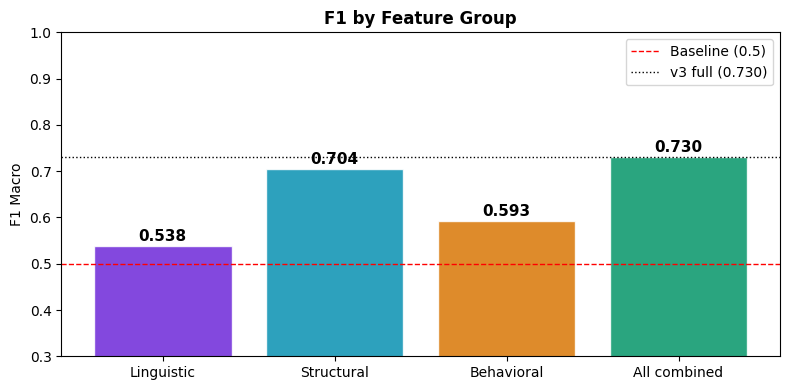


Best single group: All combined (F1=0.730)
Linguistic features alone are near baseline.
Behavioral/structural features drive accuracy.
Action: this IS your finding - contestation shows
in editor behavior, not writing style alone.


In [4]:
print("=== EXPERIMENT 3: FEATURE SUBSETS ===\n")

LINGUISTIC = ["hedging_density","def_ratio"]
STRUCTURAL = ["citation_count","section_count",
               "unique_editors","age_days","recency_ratio"]
BEHAVIORAL = ["revert_count","talk_words","talk_editors"]

results = {}

print("Linguistic only:")
results["Linguistic"], _ = run_model(LINGUISTIC, "Linguistic only")

print("\nStructural only:")
results["Structural"], _ = run_model(STRUCTURAL, "Structural only")

print("\nBehavioral (talk page) only:")
results["Behavioral"], _ = run_model(BEHAVIORAL, "Behavioral only")

print("\nAll combined:")
results["All combined"], _ = run_model(BASELINE_FEATURES, "All combined")

fig, ax = plt.subplots(figsize=(8,4))
labs = list(results.keys())
vals = list(results.values())
cols = ["#6D28D9","#0891B2","#D97706","#059669"]
bars = ax.bar(labs, vals, color=cols, alpha=0.85, edgecolor="white")
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Baseline (0.5)")
ax.axhline(f1_baseline, color="black", linestyle=":",
           linewidth=1, label=f"v3 full ({f1_baseline:.3f})")
ax.set_ylabel("F1 Macro")
ax.set_title("F1 by Feature Group", fontweight="bold")
ax.set_ylim(0.3, 1.0)
ax.legend()
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("exp3_subsets.png", dpi=150, bbox_inches="tight")
plt.show()

best = max(results, key=results.get)
print(f"\nBest single group: {best} (F1={results[best]:.3f})")
if results["Linguistic"] < 0.55:
    print("Linguistic features alone are near baseline.")
    print("Behavioral/structural features drive accuracy.")
    print("Action: this IS your finding - contestation shows")
    print("in editor behavior, not writing style alone.")
else:
    print("Linguistic features show real discriminative power.")
    print("Action: invest in richer linguistic feature extraction.")


## Experiment 4 - Topic Control

In [5]:
print("=== EXPERIMENT 4: TOPIC CONTROL ===\n")

df_topic = pd.get_dummies(df["topic"], prefix="topic", drop_first=True)
df_ctrl  = pd.concat([df.reset_index(drop=True),
                       df_topic.reset_index(drop=True)], axis=1)
topic_cols    = list(df_topic.columns)
features_ctrl = BASELINE_FEATURES + topic_cols

print("Without topic control:")
f1_noctrl, _ = run_model(BASELINE_FEATURES, "No topic control", df_ctrl)

print("\nWith topic dummies as controls:")
f1_ctrl, _ = run_model(features_ctrl, "Topic controlled", df_ctrl)

diff = f1_ctrl - f1_noctrl
print(f"\nF1 change with topic control: {diff:+.3f}")

for topic in ["geography","culture","politics_history"]:
    sub = df[df["topic"] == topic]
    n   = len(sub)
    if n < 8:
        print(f"\n{topic} (n={n}): too few for CV")
        continue
    d_sub = sub[BASELINE_FEATURES + ["label"]].dropna()
    if len(d_sub) < 8: continue
    X_sub = StandardScaler().fit_transform(d_sub[BASELINE_FEATURES].values)
    y_sub = d_sub["label"].values
    cv_   = StratifiedKFold(n_splits=min(5,len(y_sub)//2),
                             shuffle=True, random_state=42)
    m_    = LogisticRegression(class_weight="balanced",
                                max_iter=1000, random_state=42)
    f1_t  = cross_val_score(m_, X_sub, y_sub, cv=cv_, scoring="f1_macro")
    print(f"\n{topic} only (n={n}): F1={f1_t.mean():.3f} +/- {f1_t.std():.3f}")

if abs(diff) > 0.05:
    print("\nTopic IS distorting results.")
    print("Include topic dummies in final model.")
else:
    print("\nTopic has minimal effect - model is robust.")


=== EXPERIMENT 4: TOPIC CONTROL ===

Without topic control:
  [No topic control]
    F1      : 0.730 +/- 0.110
    Accuracy: 0.738 +/- 0.108
    Baseline: 0.500  Improvement: +0.238

With topic dummies as controls:
  [Topic controlled]
    F1      : 0.632 +/- 0.027
    Accuracy: 0.637 +/- 0.025
    Baseline: 0.500  Improvement: +0.137

F1 change with topic control: -0.098

geography only (n=39): F1=0.648 +/- 0.131

culture only (n=26): F1=0.524 +/- 0.313

politics_history only (n=13): F1=0.733 +/- 0.249

Topic IS distorting results.
Include topic dummies in final model.


## Experiment 5 - Pair-Level Wilcoxon (More Powerful)

In [6]:
print("=== EXPERIMENT 5: PAIR-LEVEL WILCOXON ===\n")

DIFF_FEATURES = [
    "hedging_density","def_ratio","citation_count",
    "section_count","unique_editors","recency_ratio",
    "revert_count","talk_words","talk_editors"
]

if os.path.exists("v3_matched_pairs.json"):
    with open("v3_matched_pairs.json", encoding="utf-8") as f:
        pairs = json.load(f)
    print(f"Loaded {len(pairs)} matched pairs")

    diff_records = []
    for p in pairs:
        c_title = p["contested"]["title"]
        s_title = p["stable"]["title"]
        c_row = df[df.title==c_title]
        s_row = df[df.title==s_title]
        if c_row.empty or s_row.empty: continue
        c_row = c_row.iloc[0]
        s_row = s_row.iloc[0]
        record = {}
        for feat in DIFF_FEATURES:
            record[f"diff_{feat}"] = c_row[feat] - s_row[feat]
        diff_records.append(record)

    diff_df = pd.DataFrame(diff_records)
    print(f"Pair differences: {len(diff_df)} pairs\n")

    print(f"{'Feature':<25} {'Mean diff':>10} {'C>S %':>8}  "
          f"{'Wilcoxon p':>11}  Sig?")
    print("-" * 65)
    for feat in DIFF_FEATURES:
        col  = f"diff_{feat}"
        mean = diff_df[col].mean()
        pct  = (diff_df[col]>0).mean()*100
        vals = diff_df[col].dropna()
        try:
            _, p = wilcoxon(vals)
            sig  = "YES" if p<0.05 else ("~" if p<0.10 else "no")
            print(f"  {feat:<23} {mean:>10.3f} {pct:>7.1f}%  "
                  f"{p:>11.4f}  {sig}")
        except Exception as e:
            print(f"  {feat:<23} {mean:>10.3f} {pct:>7.1f}%  "
                  f"{'error':>11}")

    print("\nNote: Wilcoxon signed-rank is more appropriate than")
    print("Mann-Whitney for matched-pair designs.")
    print("Features significant here are genuinely robust signals.")
else:
    print("v3_matched_pairs.json not found.")
    print("Run matching cell first then re-run this experiment.")


=== EXPERIMENT 5: PAIR-LEVEL WILCOXON ===

Loaded 40 matched pairs
Pair differences: 40 pairs

Feature                    Mean diff    C>S %   Wilcoxon p  Sig?
-----------------------------------------------------------------
  hedging_density              0.319    52.5%       0.0794  ~
  def_ratio                    0.004    65.0%       0.0697  ~
  citation_count              -2.475    45.0%       0.5392  no
  section_count                4.150    67.5%       0.0002  YES
  unique_editors              57.425    77.5%       0.0002  YES
  recency_ratio               -0.004    42.5%       0.7828  no
  revert_count                 0.250    25.0%       0.3057  no
  talk_words                2017.000    72.5%       0.0002  YES
  talk_editors                 3.800    60.0%       0.0497  YES

Note: Wilcoxon signed-rank is more appropriate than
Mann-Whitney for matched-pair designs.
Features significant here are genuinely robust signals.


## Experiment 6 - Random Forest vs Logistic Regression

=== EXPERIMENT 6: RF vs LR ===

  Random Forest      F1: 0.675 +/- 0.121
  Logistic Regression F1: 0.730 +/- 0.110
  Baseline              : 0.500


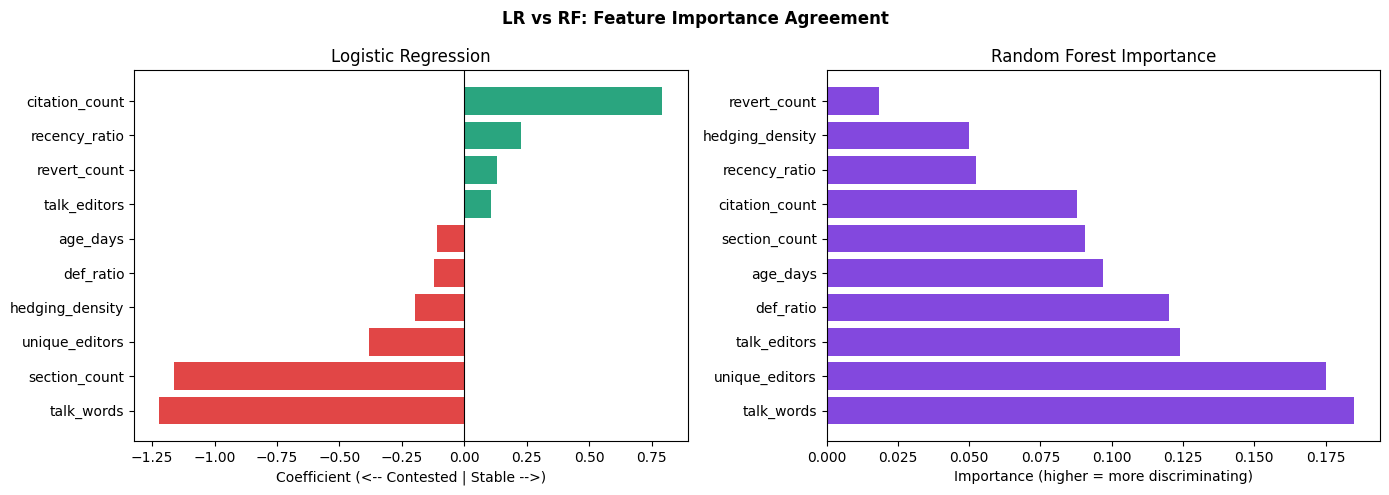


Top 3 by RF importance:
  talk_words                RF=0.1848
  unique_editors            RF=0.1753
  talk_editors              RF=0.1241

If RF and LR agree on top features: signal is robust.
If they disagree: relationship may be non-linear.


In [7]:
print("=== EXPERIMENT 6: RF vs LR ===\n")

d_rf  = df[BASELINE_FEATURES + ["label"]].dropna()
X_rf  = StandardScaler().fit_transform(d_rf[BASELINE_FEATURES].values)
y_rf  = d_rf["label"].values
cv_   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                              random_state=42, max_depth=5)
lr = LogisticRegression(class_weight="balanced",
                          max_iter=1000, random_state=42)

f1_rf  = cross_val_score(rf, X_rf, y_rf, cv=cv_, scoring="f1_macro")
f1_lr  = cross_val_score(lr, X_rf, y_rf, cv=cv_, scoring="f1_macro")

print(f"  Random Forest      F1: {f1_rf.mean():.3f} +/- {f1_rf.std():.3f}")
print(f"  Logistic Regression F1: {f1_lr.mean():.3f} +/- {f1_lr.std():.3f}")
print(f"  Baseline              : 0.500")

rf.fit(X_rf, y_rf)
lr.fit(X_rf, y_rf)

imp_df = pd.DataFrame({
    "feature":    BASELINE_FEATURES,
    "rf_importance": rf.feature_importances_,
    "lr_coef":       lr.coef_[0]
}).sort_values("rf_importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LR vs RF: Feature Importance Agreement",
             fontweight="bold")

lr_sorted = imp_df.sort_values("lr_coef")
colors_lr = ["#DC2626" if c<0 else "#059669" for c in lr_sorted["lr_coef"]]
axes[0].barh(lr_sorted["feature"], lr_sorted["lr_coef"],
             color=colors_lr, alpha=0.85)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Coefficient (<-- Contested | Stable -->)")

axes[1].barh(imp_df["feature"], imp_df["rf_importance"],
             color="#6D28D9", alpha=0.85)
axes[1].set_title("Random Forest Importance")
axes[1].set_xlabel("Importance (higher = more discriminating)")

plt.tight_layout()
plt.savefig("exp6_lr_vs_rf.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 3 by RF importance:")
for _, row in imp_df.head(3).iterrows():
    print(f"  {row['feature']:<25} RF={row['rf_importance']:.4f}")

print("\nIf RF and LR agree on top features: signal is robust.")
print("If they disagree: relationship may be non-linear.")


## Final Summary

In [8]:
print("=" * 65)
print("EXPERIMENT SUMMARY - NEXT STEPS")
print("=" * 65)
print()
print("Based on Experiment 3 (feature subsets):")
print()
print("If linguistic F1 < 0.55:")
print("  Behavioral features drive accuracy.")
print("  Your finding: contestation shows in editor behavior,")
print("  not writing style alone. Still valid and interesting.")
print("  Cross-lingual comparison: do DE editors also show")
print("  higher behavioral signals for contested articles?")
print()
print("If linguistic F1 > 0.60:")
print("  Real linguistic signal exists.")
print("  Add: expanded hedging, passive voice ratio,")
print("  semantic coherence, named entity density.")
print()
print("Based on Experiment 5 (Wilcoxon):")
print("  Features significant in paired test are your")
print("  most robust findings to report at midterm.")
print()
print("Based on Experiment 4 (topic control):")
print("  If geography dominates: stratify full collection.")
print("  Aim for ~25% per topic bucket at 200 articles.")
print("=" * 65)


EXPERIMENT SUMMARY - NEXT STEPS

Based on Experiment 3 (feature subsets):

If linguistic F1 < 0.55:
  Behavioral features drive accuracy.
  Your finding: contestation shows in editor behavior,
  not writing style alone. Still valid and interesting.
  Cross-lingual comparison: do DE editors also show
  higher behavioral signals for contested articles?

If linguistic F1 > 0.60:
  Real linguistic signal exists.
  Add: expanded hedging, passive voice ratio,
  semantic coherence, named entity density.

Based on Experiment 5 (Wilcoxon):
  Features significant in paired test are your
  most robust findings to report at midterm.

Based on Experiment 4 (topic control):
  If geography dominates: stratify full collection.
  Aim for ~25% per topic bucket at 200 articles.


In [9]:
import json
with open("v4_contested.json") as f:
    data = json.load(f)

print(f"Total collected: {len(data)}")
from collections import Counter
topics = Counter(a["topic"] for a in data)
for t, c in sorted(topics.items()):
    print(f"  {t:<20} {c}")

Total collected: 50
  culture              11
  geography            28
  other                1
  politics_history     9
  science              1


In [10]:
import json, re, requests, time

HEADERS = {"User-Agent": "UniMannheim-SMDA-v4/1.0 (student research)"}
VALID_YEARS = [2022, 2023, 2024, 2025]

# Load the template cache
with open("v4_template_titles_Template_POV.json") as f:
    pov_titles = json.load(f)

# Already collected
with open("v4_contested.json") as f:
    already = {a["title"] for a in json.load(f)}

remaining = [t for t in pov_titles if t not in already]
print(f"Remaining candidates from POV cache: {len(remaining)}")

# Quick sample test - check 20 articles for date filter
print("\nTesting date filter on first 20 candidates...")
passed = 0
failed_date = 0
failed_other = 0

for title in remaining[:20]:
    r = requests.get("https://en.wikipedia.org/w/api.php",
        headers=HEADERS, params={
            "action": "query", "titles": title,
            "prop": "revisions", "rvprop": "content",
            "rvslots": "main", "rvlimit": 1, "format": "json"
        }, timeout=15)
    if r.status_code != 200:
        failed_other += 1
        continue
    try:
        text = list(r.json()["query"]["pages"].values())[0]["revisions"][0]["slots"]["main"]["*"]
        templates = re.findall(r'\{\{(?:POV|Neutrality)[^}]*\}\}', text, re.IGNORECASE)
        has_recent = any(
            re.search(r'date=\w+ (20\d{2})', t) and
            int(re.search(r'date=\w+ (20\d{2})', t).group(1)) in VALID_YEARS
            for t in templates
        )
        if has_recent:
            passed += 1
            print(f"  PASS: {title[:50]}")
        else:
            failed_date += 1
    except:
        failed_other += 1
    time.sleep(2)

print(f"\nResults from 20 candidates:")
print(f"  Pass date filter : {passed}")
print(f"  Fail date filter : {failed_date}")
print(f"  API errors       : {failed_other}")
print(f"\nEstimated pass rate: {passed/20*100:.0f}%")
print(f"Estimated articles available: {len(remaining) * passed // 20}")

Remaining candidates from POV cache: 454

Testing date filter on first 20 candidates...
  PASS: Anxiety

Results from 20 candidates:
  Pass date filter : 1
  Fail date filter : 1
  API errors       : 18

Estimated pass rate: 5%
Estimated articles available: 22
